# 04 — Model Training & Evaluation
## FMD Outbreak Prediction — Sri Lanka (2017–2024)

**Objective:** Train and compare multiple machine learning models using
a proper time-series evaluation strategy (walk-forward validation).

### Why Walk-Forward Validation?
Unlike random train/test splits, FMD outbreaks are **time-dependent**.
We can't use future data to predict the past. So we use an expanding
window approach:
- Train on all years up to Y-1, test on year Y
- Test years: **2022, 2023, 2024**

### Models to Compare
1. **Seasonal Naive** (baseline) — predict same as last year
2. **Logistic Regression** — simple linear model
3. **Random Forest** — ensemble of decision trees
4. **Gradient Boosting** — sequential boosted trees
5. **XGBoost** — optimized gradient boosting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import clone
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, roc_auc_score,
                             confusion_matrix, classification_report)

BASE_DIR  = r'..'
DATA_FILE = os.path.join(BASE_DIR, 'data', 'processed',
                         'FMD_model_ready_main refined_final_dataset.csv')
PLOT_DIR  = os.path.join(BASE_DIR, 'plots', '04_model_comparison')
os.makedirs(PLOT_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE)
print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset: 2400 rows × 26 columns


---
## Step 1: Prepare Features

We encode the district column and define which columns are features
vs. identifiers vs. the target.

In [2]:
le = LabelEncoder()
df['district_enc'] = le.fit_transform(df['district'])

TARGET = 'Outbreak status'
drop_cols = ['year', 'month_num', 'district', 'PCODE', TARGET]
feature_cols = [c for c in df.columns if c not in drop_cols]

print(f"Target: {TARGET}")
print(f"Features ({len(feature_cols)}):")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {c}")

Target: Outbreak status
Features (22):
   1. sin_month
   2. cos_month
   3. monsoon_phase_First_Inter_Monsoon
   4. monsoon_phase_SW_Monsoon
   5. monsoon_phase_Second_Inter_Monsoon
   6. monsoon_phase_NE_Monsoon
   7. rainfall_mm
   8. r3h
   9. rfq
  10. rain_lag1
  11. rain_lag2
  12. rfq_lag1
  13. lat
  14. lon
  15. humidity
  16. wind_speed
  17. temp_lag1
  18. humidity_lag1
  19. wind_lag1
  20. buffalo_density
  21. livestock_density
  22. district_enc


---
## Step 2: Seasonal Naive Baseline

The simplest possible "model": predict whatever happened in the **same
district, same month, previous year**. Any useful ML model must beat this.

In [3]:
def seasonal_naive(df, test_year):
    train = df[df['year'] < test_year]
    test  = df[df['year'] == test_year].copy()
    preds = []
    for _, row in test.iterrows():
        prev = train[(train['district'] == row['district']) &
                      (train['month_num'] == row['month_num']) &
                      (train['year'] == test_year - 1)]
        preds.append(int(prev.iloc[0][TARGET]) if len(prev) > 0 else 0)
    y_true, y_pred = test[TARGET].values, np.array(preds)
    return {'Model': 'Seasonal Naive', 'Test year': test_year,
            'Precision': '-',
            'Recall': round(recall_score(y_true, y_pred, zero_division=0), 3),
            'F1': round(f1_score(y_true, y_pred, zero_division=0), 3),
            'PR-AUC': '-', 'ROC-AUC': '-'}

---
## Step 3: Walk-Forward Evaluation Function

This function trains a model on all data before `test_year` and
evaluates it on `test_year`. Features are scaled using StandardScaler.

In [4]:
def walk_forward_eval(df, model, model_name, test_year, feature_cols):
    train = df[df['year'] < test_year]
    test  = df[df['year'] == test_year]
    X_train, y_train = train[feature_cols], train[TARGET]
    X_test,  y_test  = test[feature_cols],  test[TARGET]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = (model.predict_proba(X_test_s)[:, 1]
              if hasattr(model, 'predict_proba') else None)

    prec    = precision_score(y_test, y_pred, zero_division=0)
    rec     = recall_score(y_test, y_pred, zero_division=0)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    pr_auc  = (average_precision_score(y_test, y_prob)
               if y_prob is not None else 0)
    roc_auc = (roc_auc_score(y_test, y_prob)
               if y_prob is not None and len(np.unique(y_test)) > 1 else 0)

    return {'Model': model_name, 'Test year': test_year,
            'Precision': round(prec, 3), 'Recall': round(rec, 3),
            'F1': round(f1, 3), 'PR-AUC': round(pr_auc, 3),
            'ROC-AUC': round(roc_auc, 3)}

---
## Step 4: Run All Models Across All Test Years

In [5]:
test_years = [2022, 2023, 2024]

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=9.5,
        use_label_encoder=False, eval_metric='logloss', random_state=42),
}

results = []
for yr in test_years:
    print(f"\n{'='*50}")
    print(f"  Test Year: {yr}  |  Training: 2017–{yr-1}")
    print(f"{'='*50}")
    results.append(seasonal_naive(df, yr))
    for name, mdl in models.items():
        res = walk_forward_eval(df, clone(mdl), name, yr, feature_cols)
        results.append(res)
        print(f"  {name:25s} → F1={res['F1']:.3f}  Recall={res['Recall']:.3f}")

results_df = pd.DataFrame(results)


  Test Year: 2022  |  Training: 2017–2021


  Logistic Regression       → F1=0.321  Recall=0.750


  Random Forest             → F1=0.050  Recall=0.028


  Gradient Boosting         → F1=0.217  Recall=0.139


  XGBoost                   → F1=0.222  Recall=0.194

  Test Year: 2023  |  Training: 2017–2022


...

  Random Forest             → F1=0.133  Recall=0.083


  Gradient Boosting         → F1=0.250  Recall=0.333
  XGBoost                   → F1=0.359  Recall=0.583

  Test Year: 2024  |  Training: 2017–2023


  Logistic Regression       → F1=0.613  Recall=0.731


  Random Forest             → F1=0.050  Recall=0.026


  Gradient Boosting         → F1=0.163  Recall=0.090
  XGBoost                   → F1=0.264  Recall=0.154


---
## Step 5: Results Table

In [6]:
print("\n" + "="*80)
print("FULL RESULTS TABLE")
print("="*80)
print(results_df.to_string(index=False))

# Save
results_df.to_csv(os.path.join(BASE_DIR, 'data', 'processed',
                                'model_comparison_final_model result.csv'),
                   index=False)
print("\n✅ Results saved!")


FULL RESULTS TABLE
              Model  Test year Precision  Recall    F1 PR-AUC ROC-AUC
     Seasonal Naive       2022         -   0.167 0.179      -       -
Logistic Regression       2022     0.205   0.750 0.321  0.278    0.72
      Random Forest       2022      0.25   0.028 0.050  0.267   0.696
  Gradient Boosting       2022       0.5   0.139 0.217  0.259   0.701
            XGBoost       2022     0.259   0.194 0.222  0.273   0.684
     Seasonal Naive       2023         -   0.250 0.125      -       -
Logistic Regression       2023      0.09   0.833 0.163   0.16   0.808
      Random Forest       2023     0.333   0.083 0.133  0.222   0.836
  Gradient Boosting       2023       0.2   0.333 0.250  0.148   0.784
            XGBoost       2023     0.259   0.583 0.359  0.191   0.709
     Seasonal Naive       2024         -   0.128 0.222      -       -
Logistic Regression       2024     0.528   0.731 0.613  0.648    0.82
      Random Forest       2024       1.0   0.026 0.050  0.696   0.869


---
## Step 6: Model Comparison Charts

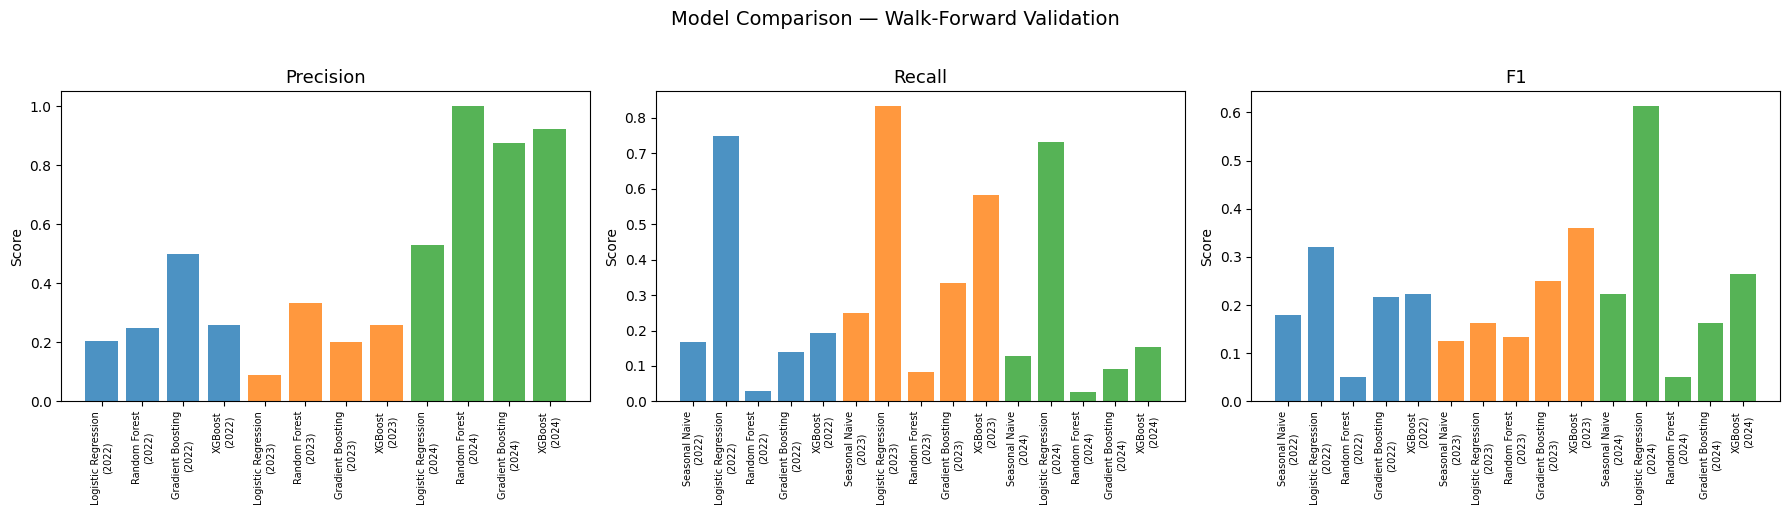

✅ Saved!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['Precision', 'Recall', 'F1']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    for yr in test_years:
        sub = results_df[results_df['Test year'] == yr].copy()
        sub[metric] = pd.to_numeric(sub[metric], errors='coerce')
        sub = sub.dropna(subset=[metric])
        ax.bar([f"{row['Model']}\n({yr})" for _, row in sub.iterrows()],
               sub[metric].values, alpha=0.8)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=90, labelsize=7)

plt.suptitle('Model Comparison — Walk-Forward Validation',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'model_comparison_chart.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

---
## Step 7: F1 Score per Test Year

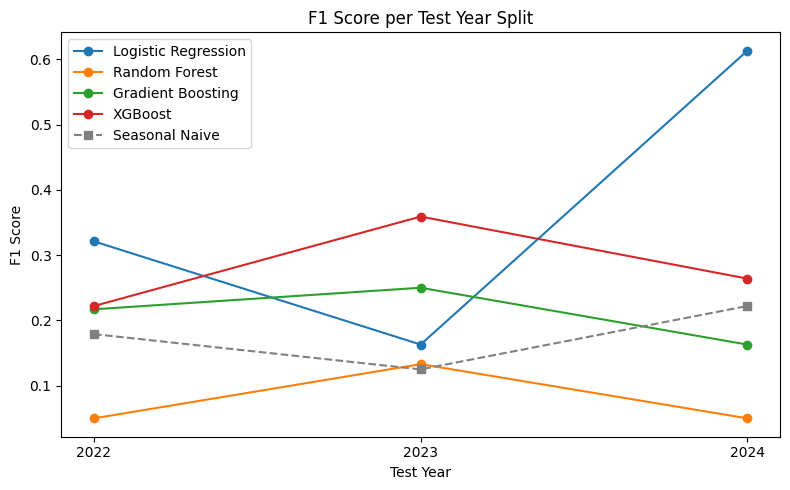

✅ Saved!


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for name in list(models.keys()) + ['Seasonal Naive']:
    sub = results_df[results_df['Model'] == name].copy()
    sub['F1'] = pd.to_numeric(sub['F1'], errors='coerce')
    style = '--' if name == 'Seasonal Naive' else '-'
    color = 'gray' if name == 'Seasonal Naive' else None
    marker = 's' if name == 'Seasonal Naive' else 'o'
    ax.plot(sub['Test year'].values, sub['F1'].values,
            marker=marker, linestyle=style, color=color, label=name)

ax.set_xlabel('Test Year')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score per Test Year Split')
ax.legend()
ax.set_xticks(test_years)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'f1_per_split.png'), dpi=150)
plt.show()
print("✅ Saved!")

---
## Conclusion

Based on the walk-forward validation results, we select the best
performing model for final predictions in Notebook 05.

**Key observations:**
- The Seasonal Naive baseline is weak — ML models add clear value
- Class imbalance handling (`class_weight='balanced'`, `scale_pos_weight`)
  is essential
- Performance varies across test years — this is expected with rare events

**Next:** Notebook 05 will train the final model on 2017–2023 and
generate detailed 2024 predictions.